## Cuaderno con graficas descriptivas marzo 4

In [1]:
import pandas as pd

In [4]:
df_despacho=pd.read_csv('../datos/raw/Despachoprogramadorecursosdegeneracion.csv')
df_desglose = pd.read_excel("../datos/raw/desglose.xlsx",header=3)

In [3]:
df_despacho

,FechaHora,CodigoDuracion,CodigoElementoGeneracion,Valor
0,2025-08-11 00:00:00,PT1H,2QBW,18380
1,2025-08-11 00:00:00,PT1H,2QEK,35000
2,2025-08-11 00:00:00,PT1H,2QRL,650
3,2025-08-11 00:00:00,PT1H,2QV2,6000
4,2025-08-11 00:00:00,PT1H,2R22,18000
...,...,...,...,...
1264514,2025-04-05 23:00:00,PT1H,SLVJ,95000
1264515,2025-04-05 23:00:00,PT1H,SMI1,25000
1264516,2025-04-05 23:00:00,PT1H,SNC1,700
1264517,2025-04-05 23:00:00,PT1H,SNCR,729000


In [14]:
id_termicas=df_desglose[df_desglose['Tipo Generación']=='TERMICA']['Código SIC'].unique()
id_hidraulicas=df_desglose[df_desglose['Tipo Generación']=='HIDRAULICA']['Código SIC'].unique()      
id_solar=df_desglose[df_desglose['Tipo Generación']=='SOLAR']['Código SIC'].unique()

In [21]:
df_despacho['hora']=pd.to_datetime(df_despacho['FechaHora']).dt.hour
df_despacho['fecha']=pd.to_datetime(df_despacho['FechaHora']).dt.date

In [35]:
df_despacho_termica=df_despacho[df_despacho['CodigoElementoGeneracion'].isin(id_termicas)]
df_despacho_hidraulica=df_despacho[df_despacho['CodigoElementoGeneracion'].isin(id_hidraulicas)]
df_despacho_solar=df_despacho[df_despacho['CodigoElementoGeneracion'].isin(id_solar)]

## Despacho por hora

In [38]:
import pandas as pd

def mean_por_hora(df, col_fecha="FechaHora", col_cantidad="Valor"):
    df = df.copy()
    
    # Asegurar datetime
    df[col_fecha] = pd.to_datetime(df[col_fecha])
    
    # 1️⃣ Sumar todas las unidades por timestamp
    df_total = (
        df.groupby(col_fecha)[col_cantidad]
        .sum()
        .reset_index()
    )
    
    # 2️⃣ Extraer hora
    df_total["hora"] = df_total[col_fecha].dt.hour
    
    # 3️⃣ Mean por hora sobre todas las fechas
    df_mean = (
        df_total.groupby("hora")[col_cantidad]
        .mean()
        .reset_index()
    )
    
    return df_mean

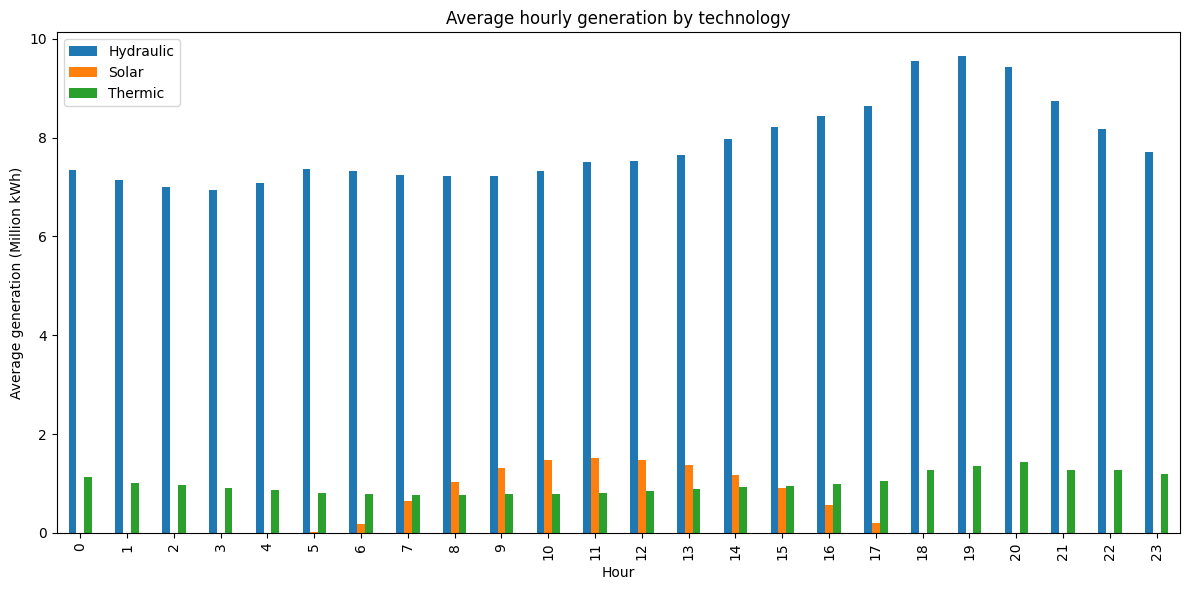

In [50]:
# Apply function to each technology dataframe
thermic_mean = mean_por_hora(df_despacho_termica)
solar_mean = mean_por_hora(df_despacho_solar)
hydraulic_mean = mean_por_hora(df_despacho_hidraulica)

# Merge results into a single dataframe
df_plot = (
    thermic_mean.rename(columns={"Valor": "Thermic"})
    .merge(
        solar_mean.rename(columns={"Valor": "Solar"}),
        on="hora"
    )
    .merge(
        hydraulic_mean.rename(columns={"Valor": "Hydraulic"}),
        on="hora"
    )
)

# Scale values to millions (1e6)
df_plot[["Thermic", "Solar", "Hydraulic"]] = (
    df_plot[["Thermic", "Solar", "Hydraulic"]] / 1e6
)

# --- PLOT ---
import matplotlib.pyplot as plt

df_plot.set_index("hora")[["Hydraulic", "Solar", "Thermic"]].plot(
    kind="bar",
    figsize=(12,6)
)

plt.xlabel("Hour")
plt.ylabel("Average generation (Million kWh)")
plt.title("Average hourly generation by technology")
plt.legend(["Hydraulic", "Solar", "Thermic"])
plt.tight_layout()
plt.show()



## Despacho por fecha

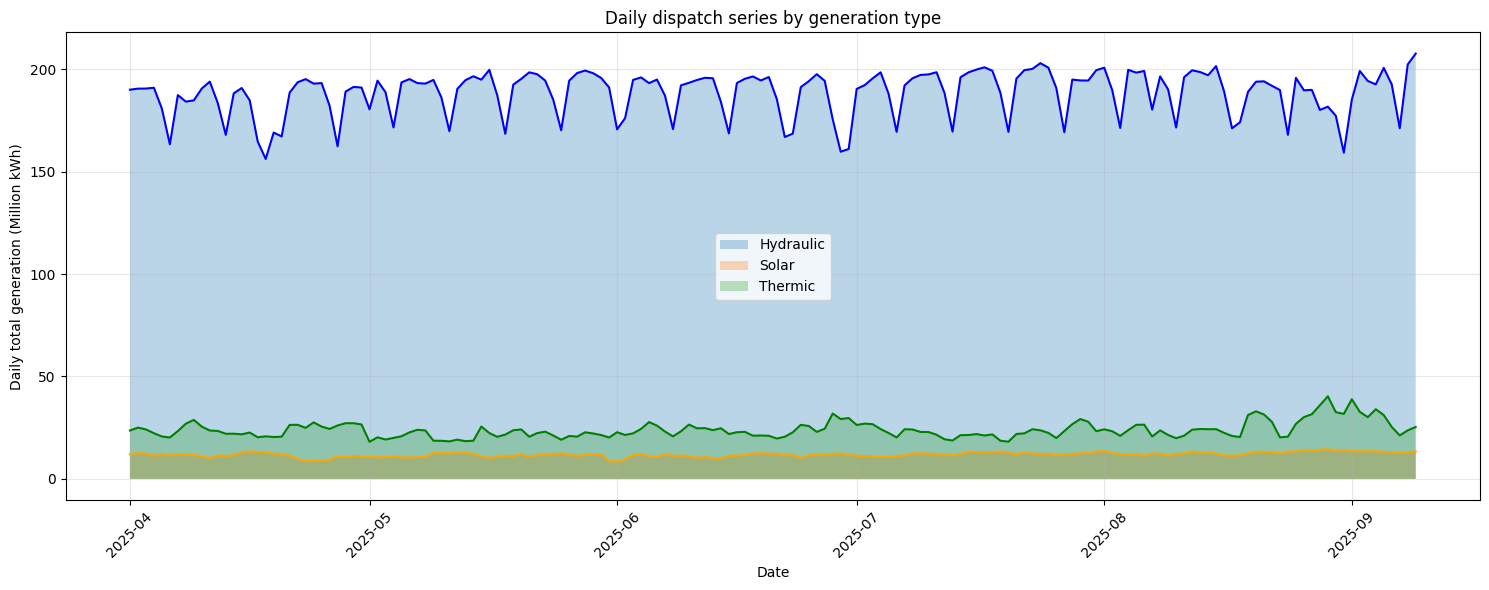

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1️⃣ Función para daily dispatch series ---
def daily_dispatch_series(df, col_fecha="FechaHora", col_valor="Valor"):
    """
    Compute daily total dispatch per dataframe.
    Returns a dataframe with 'date' and daily total 'Valor'.
    """
    df = df.copy()
    df[col_fecha] = pd.to_datetime(df[col_fecha])
    
    # Sum over all units per timestamp, then per day
    df_daily = df.groupby(df[col_fecha].dt.date)[col_valor].sum().reset_index()
    df_daily.rename(columns={col_fecha: "date", col_valor: "Valor"}, inplace=True)
    
    return df_daily

# --- 2️⃣ Aplicar a cada tipo de generación ---
thermic_daily = daily_dispatch_series(df_despacho_termica)
solar_daily = daily_dispatch_series(df_despacho_solar)
hydraulic_daily = daily_dispatch_series(df_despacho_hidraulica)

# --- 3️⃣ Unir resultados ---
df_daily_plot = thermic_daily.rename(columns={"Valor": "Thermic"}).merge(
    solar_daily.rename(columns={"Valor": "Solar"}), on="date"
).merge(
    hydraulic_daily.rename(columns={"Valor": "Hydraulic"}), on="date"
)

# Escalar a millones
df_daily_plot[["Thermic", "Solar", "Hydraulic"]] /= 1e6

# --- 4️⃣ Graficar serie de tiempo ---
plt.figure(figsize=(15,6))

plt.fill_between(df_daily_plot["date"], df_daily_plot["Hydraulic"], alpha=0.3, label="Hydraulic")
plt.fill_between(df_daily_plot["date"], df_daily_plot["Solar"], alpha=0.3, label="Solar")
plt.fill_between(df_daily_plot["date"], df_daily_plot["Thermic"], alpha=0.3, label="Thermic")

plt.plot(df_daily_plot["date"], df_daily_plot["Hydraulic"], color="blue")
plt.plot(df_daily_plot["date"], df_daily_plot["Solar"], color="orange")
plt.plot(df_daily_plot["date"], df_daily_plot["Thermic"], color="green")

plt.xlabel("Date")
plt.ylabel("Daily total generation (Million kWh)")
plt.title("Daily dispatch series by generation type")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

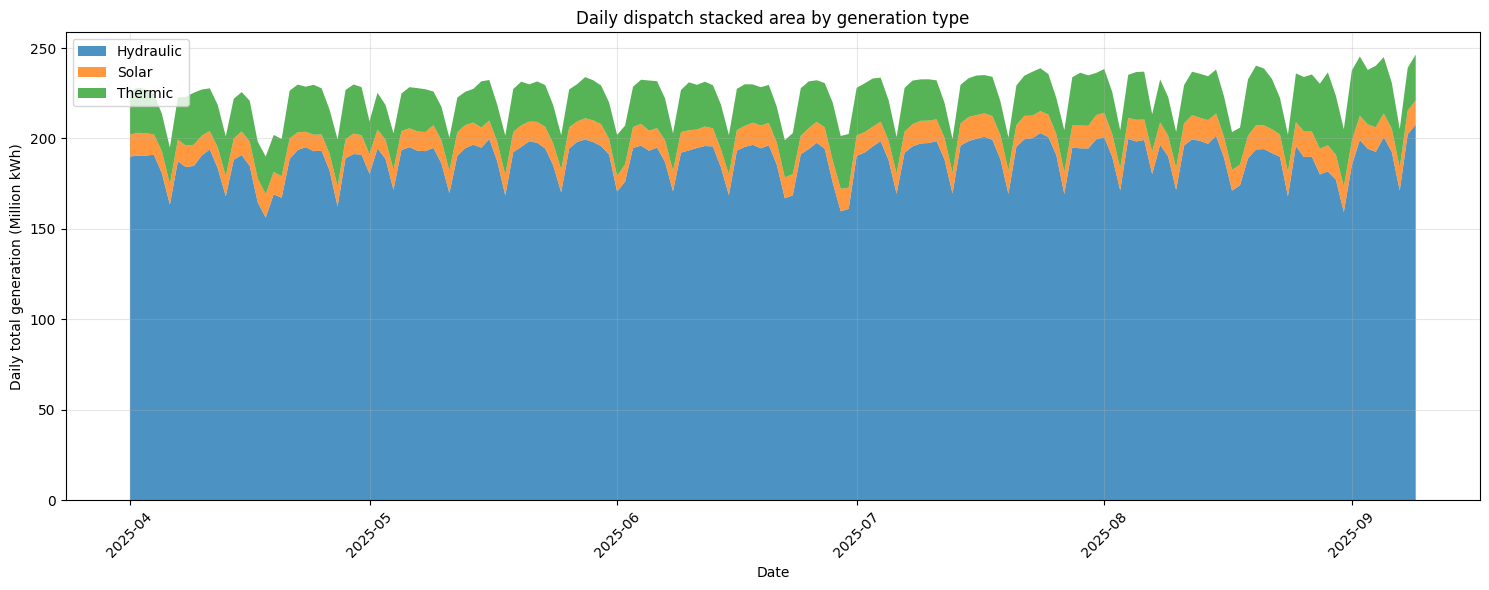

In [59]:
plt.figure(figsize=(15,6))

# Softer, visually pleasant colors
soft_colors = ["#1f77b4",  # blue (softer than default)
               "#ff7f0e",  # orange
               "#2ca02c"]  # green

plt.stackplot(
    df_daily_plot["date"],
    df_daily_plot["Hydraulic"],
    df_daily_plot["Solar"],
    df_daily_plot["Thermic"],
    labels=["Hydraulic", "Solar", "Thermic"],
    colors=soft_colors,
    alpha=0.8
)

plt.xlabel("Date")
plt.ylabel("Daily total generation (Million kWh)")
plt.title("Daily dispatch stacked area by generation type")
plt.legend(loc="upper left")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()